In [40]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from glob import glob
from tqdm import tqdm
import xarray as xr
import os, sys
import scipy
import pandas as pd
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from scipy import stats

from scipy import interpolate

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# from cinplaAnalysis.utils import *
import quantities as pq
%matplotlib inline

In [41]:
from icsd import StandardCSD, DeltaiCSD, StepiCSD

In [42]:
import matplotlib

font = {'size'   : 12}

matplotlib.rc('font', **font)

In [43]:
matplotlib.rcParams['savefig.pad_inches'] = 0

In [44]:
def plotFig(ax,csd,breaks=None,absmax=None,timeLimited=False,plotCB=True,xlabels=False,title=None):

    if breaks is not None:
        for b in breaks:
            ax.plot([0,3000],[b,b],c='k')

    if absmax is None:
        absmax = np.max(np.abs(csd))

    rms = np.mean(np.sqrt(csd**2))
    im = ax.imshow(np.array(csd), origin='lower',cmap='bwr_r',vmin =-absmax,vmax=absmax)
    #im = ax.imshow(np.array(csd)/rms, origin='lower',cmap='bwr_r',vmin=-10,vmax=10)#, vmin =-absmax,vmax=absmax, cmap='bwr_r')
    ax.axis(ax.axis('tight'))

    if plotCB:
        cb = plt.colorbar(im, ax=ax)
        cb.formatter.set_powerlimits((0,0))


    ax.set_yticklabels([])

    if xlabels:
        ax.set_xticks([0,50],labels=['0','50'])
        # ax.set_xlabel('Time (ms)')
    else:
        ax.set_xticklabels([])

    if timeLimited:
        ax.set_xlim([50,100])
    else:
        ax.set_xlim([0,50])

    if title:
        plt.title(title)

    plt.tight_layout()

In [45]:
def produce_iCSD(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,'tol':1e-12
    }
    
    
    icsd_high = StepiCSD(**step_input_high)


    return icsd_high

    

In [46]:
def produce_iCSD_all(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    step_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':20E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low = {
        'lfp' : totalLFPLowRes.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 40 * np.arange(0,51) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':40E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low_half = {
        'lfp' : totalLFPLowResHalf.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 80 * np.arange(0,totalLFPLowResHalf.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':80E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
    
    step_input_low_quarter = {
        'lfp' : totalLFPLowResQuarter.T * 1E-3 * pq.V,      # [mV] -> [V],
        'coord_electrode' : 160 * np.arange(0,totalLFPLowResQuarter.shape[1]) * 1e-6 * pq.m,
        'sigma' : sigma,
        'h':160E-6 * pq.m ,
        'f_type' : 'gaussian',
        'f_order' : (3, 1),
        'diam': diam,
        'tol':1e-12
    }
     
    icsd_high = StepiCSD(**step_input_high)
    icsd_low = StepiCSD(**step_input_low)
    icsd_low_half = StepiCSD(**step_input_low_half)
    icsd_low_quarter = StepiCSD(**step_input_low_quarter)


    return icsd_high, icsd_low, icsd_low_half, icsd_low_quarter

In [47]:
def produce_sCSD(data,lfpIdx,diam):
    
    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    sigma = 0.277 * pq.S / pq.m                         # [S/m] or [1/(ohm*m)]
    sigma_top = 0.277 * pq.S / pq.m                     # [S/m] or [1/(ohm*m)]
    
    # Input dictionaries for each method
    
    
    std_input_high = {
        'lfp' : totalLFPHighRes.T * 1E-3 * pq.V,   # [mV] -> [V],
        'coord_electrode' : 20 * np.arange(0,101) * 1e-6 * pq.m,
        'sigma' : sigma,
        'f_type' : 'gaussian',
        'f_order' : (3, 1)
    }   
    
    
    icsd_high_std = StandardCSD(**std_input_high)

    return icsd_high_std

In [48]:
def produce_oCSD(data,lfp_idx,disk_fullDensity_idx):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    objective_disk_full_highRes = data[:,disk_fullDensity_idx] # oCSD, 20 um spacing

    # objective_disk_full_lowRes = np.zeros_like(totalLFPLowRes)
    # objective_disk_half_lowRes = np.zeros_like(totalLFPLowResHalf)
    # objective_disk_quarter_lowRes = np.zeros_like(totalLFPLowResQuarter)
    
    # for l in range(objective_disk_full_lowRes.shape[1]):
    #     if l == 0:
    #         objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l+1]
    #     elif l == objective_disk_full_lowRes.shape[1]-1:
    #         objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]
    #     else:
    #         objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]+.5*objective_disk_full_highRes[:,2*l+1]
    
    # for l in range(objective_disk_half_lowRes.shape[1]):
    #     if l == 0:
    #         objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
    #     elif l == objective_disk_half_lowRes.shape[1]-1:
    #         objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
    #     else:
    #         objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]
    
    # for l in range(objective_disk_quarter_lowRes.shape[1]):
    #     if l == 0:
    #         objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
    #     elif l == objective_disk_quarter_lowRes.shape[1]-1:
    #         objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
    #     else:
    #         objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]

    return objective_disk_full_highRes

In [49]:
def produce_oCSD_all(data,lfp_idx,disk_fullDensity_idx):

    ### Calculates oCSD for 40, 80, and 160 um electrode spacing, with rho of 500 um, by taking the sum of neighboring electrodes in the 20 um case

    totalLFPHighRes = data[:,lfpIdx] # LFP, 20 um spacing
    totalLFPLowRes = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:2] # LFP, 40 um spacing
    totalLFPLowResHalf = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:4] # LFP, 80 um spacing
    totalLFPLowResQuarter = totalLFPHighRes[:,0:totalLFPHighRes.shape[1]:8] # LFP, 160 um spacing

    objective_disk_full_highRes = data[:,disk_fullDensity_idx] # oCSD, 20 um spacing

    objective_disk_full_lowRes = np.zeros_like(totalLFPLowRes)
    objective_disk_half_lowRes = np.zeros_like(totalLFPLowResHalf)
    objective_disk_quarter_lowRes = np.zeros_like(totalLFPLowResQuarter)
    
    for l in range(objective_disk_full_lowRes.shape[1]):
        if l == 0:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l+1]
        elif l == objective_disk_full_lowRes.shape[1]-1:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]
        else:
            objective_disk_full_lowRes[:,l] = objective_disk_full_highRes[:,2*l]+.5*objective_disk_full_highRes[:,2*l-1]+.5*objective_disk_full_highRes[:,2*l+1]
    
    for l in range(objective_disk_half_lowRes.shape[1]):
        if l == 0:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l+1]
        elif l == objective_disk_half_lowRes.shape[1]-1:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]
        else:
            objective_disk_half_lowRes[:,l] = objective_disk_full_lowRes[:,2*l]+.5*objective_disk_full_lowRes[:,2*l-1]+.5*objective_disk_full_lowRes[:,2*l+1]
    
    for l in range(objective_disk_quarter_lowRes.shape[1]):
        if l == 0:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l+1]
        elif l == objective_disk_quarter_lowRes.shape[1]-1:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]
        else:
            objective_disk_quarter_lowRes[:,l] = objective_disk_half_lowRes[:,2*l]+.5*objective_disk_half_lowRes[:,2*l-1]+.5*objective_disk_half_lowRes[:,2*l+1]

    return objective_disk_full_highRes, objective_disk_full_lowRes, objective_disk_half_lowRes, objective_disk_quarter_lowRes

In [30]:
highResNoNoiseNoActive.shape

(1550, 204)

In [62]:
#highResOriginal = np.load('/mnt/c/Users/tharayil/Downloads/csd_paper/highRes/total.npy')[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um

highResNoNoiseNoActive = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive/total.npy')[-50:] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um

lfpIdx = np.arange(101) 
diam = 400E-6 * pq.m                              # [m]

icsd_high_NoNoiseNoActive_200, icsd_low_NoNoiseNoActive_200, icsd_half_NoNoiseNoActive_200, icsd_quarter_NoNoiseNoActive_200 = produce_iCSD_all(highResNoNoiseNoActive,lfpIdx,diam)


diam = 200E-6 * pq.m                              # [m]



icsd_high_NoNoiseNoActive_100, icsd_low_NoNoiseNoActive_100, icsd_half_NoNoiseNoActive_100, icsd_quarter_NoNoiseNoActive_100 = produce_iCSD_all(highResNoNoiseNoActive,lfpIdx,diam)
# icsd_L4_NoNoiseNoActive_100 = produce_iCSD(L4NoNoise,lfpIdx,diam)
# icsd_L5_NoNoiseNoActive_100 = produce_iCSD(L5NoNoise,lfpIdx,diam)

diam = 100E-6 * pq.m                              # [m]


icsd_high_NoNoiseNoActive_50, icsd_low_NoNoiseNoActive_50, icsd_half_NoNoiseNoActive_50, icsd_quarter_NoNoiseNoActive_50 = produce_iCSD_all(highResNoNoiseNoActive,lfpIdx,diam)
# icsd_L4_NoNoiseNoActive_100 = produce_iCSD(L4NoNoise,lfpIdx,diam)
# icsd_L5_NoNoiseNoActive_100 = produce_iCSD(L5NoNoise,lfpIdx,diam)

diam = 40E-6 * pq.m                              # [m]

icsd_high_NoNoiseNoActive_20, icsd_low_NoNoiseNoActive_20, icsd_half_NoNoiseNoActive_20, icsd_quarter_NoNoiseNoActive_20 = produce_iCSD_all(highResNoNoiseNoActive,lfpIdx,diam)

noNoiseNoActive_50 = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_50um/total.npy')

idx_100 = np.arange(101) # Indices in the output file for objective disk CSD with 100 um rho

noNoiseNoActive_largeradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_midRho/total.npy')

ocsd_noNoiseNoActive_100, ocsd_low_noNoiseNoActive_100, ocsd_half_noNoiseNoActive_100, ocsd_quarter_noNoiseNoActive_100 = produce_oCSD_all(noNoiseNoActive_largeradius,lfpIdx,idx_100)

noNoiseNoActive = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_50um/total.npy')

ocsd_noNoiseNoActive_200, ocsd_low_noNoiseNoActive_200, ocsd_half_noNoiseNoActive_200, ocsd_quarter_noNoiseNoActive_200 = produce_oCSD_all(noNoiseNoActive,lfpIdx,np.arange(202,303))
# ocsd_noNoiseNoActive_100, ocsd_low_noNoiseNoActive_100, ocsd_half_noNoiseNoActive_100, ocsd_quarter_noNoiseNoActive_100 = produce_oCSD_all(noNoiseNoActive,lfpIdx,np.arange(404,505))
ocsd_noNoiseNoActive_50, ocsd_low_noNoiseNoActive_50, ocsd_half_noNoiseNoActive_50, ocsd_quarter_noNoiseNoActive_50 = produce_oCSD_all(noNoiseNoActive,lfpIdx,np.arange(303,404))
ocsd_noNoiseNoActive_20, ocsd_low_noNoiseNoActive_20, ocsd_half_noNoiseNoActive_20, ocsd_quarter_noNoiseNoActive_20 = produce_oCSD_all(noNoiseNoActive,lfpIdx,np.arange(505,606))
                                

In [63]:
#highResOriginal = np.load('/mnt/c/Users/tharayil/Downloads/csd_paper/highRes/total.npy')[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um

highResNoActive = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise/total.npy')[-50:] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um

lfpIdx = np.arange(101) 
diam = 400E-6 * pq.m                              # [m]

icsd_high_NoActive_200, icsd_low_NoActive_200, icsd_half_NoActive_200, icsd_quarter_NoActive_200 = produce_iCSD_all(highResNoActive,lfpIdx,diam)


diam = 200E-6 * pq.m                              # [m]



icsd_high_NoActive_100, icsd_low_NoActive_100, icsd_half_NoActive_100, icsd_quarter_NoActive_100 = produce_iCSD_all(highResNoActive,lfpIdx,diam)
# icsd_L4_NoNoiseNoActive_100 = produce_iCSD(L4NoNoise,lfpIdx,diam)
# icsd_L5_NoNoiseNoActive_100 = produce_iCSD(L5NoNoise,lfpIdx,diam)

diam = 100E-6 * pq.m                              # [m]


icsd_high_NoActive_50, icsd_low_NoActive_50, icsd_half_NoActive_50, icsd_quarter_NoActive_50 = produce_iCSD_all(highResNoActive,lfpIdx,diam)
# icsd_L4_NoNoiseNoActive_100 = produce_iCSD(L4NoNoise,lfpIdx,diam)
# icsd_L5_NoNoiseNoActive_100 = produce_iCSD(L5NoNoise,lfpIdx,diam)

diam = 40E-6 * pq.m                              # [m]

icsd_high_NoActive_20, icsd_low_NoActive_20, icsd_half_NoActive_20, icsd_quarter_NoActive_20 = produce_iCSD_all(highResNoActive,lfpIdx,diam)

NoActive_50 = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_50um/total.npy')

idx_100 = np.arange(101) # Indices in the output file for objective disk CSD with 100 um rho

NoActive_largeradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_midRho/total.npy')

ocsd_NoActive_100, ocsd_low_NoActive_100, ocsd_half_NoActive_100, ocsd_quarter_NoActive_100 = produce_oCSD_all(NoActive_largeradius,lfpIdx,idx_100)

NoActive = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_50um/total.npy')

ocsd_NoActive_200, ocsd_low_NoActive_200, ocsd_half_NoActive_200, ocsd_quarter_NoActive_200 = produce_oCSD_all(NoActive,lfpIdx,np.arange(202,303))
# ocsd_noNoiseNoActive_100, ocsd_low_noNoiseNoActive_100, ocsd_half_noNoiseNoActive_100, ocsd_quarter_noNoiseNoActive_100 = produce_oCSD_all(noNoiseNoActive,lfpIdx,np.arange(404,505))
ocsd_NoActive_50, ocsd_low_NoActive_50, ocsd_half_NoActive_50, ocsd_quarter_NoActive_50 = produce_oCSD_all(NoActive,lfpIdx,np.arange(303,404))
ocsd_NoActive_20, ocsd_low_NoActive_20, ocsd_half_NoActive_20, ocsd_quarter_NoActive_20 = produce_oCSD_all(NoActive,lfpIdx,np.arange(505,606))
                                

In [64]:
#highResOriginal = np.load('/mnt/c/Users/tharayil/Downloads/csd_paper/highRes/total.npy')[1500:1550] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um

highResNoNoise = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise/total.npy')[-50:] # Loads LFP and oCSD averaged over trials, 20 um spacing, rho=500um

lfpIdx = np.arange(101) 
diam = 400E-6 * pq.m                              # [m]

icsd_high_NoNoise_200, icsd_low_NoNoise_200, icsd_half_NoNoise_200, icsd_quarter_NoNoise_200 = produce_iCSD_all(highResNoNoise,lfpIdx,diam)


diam = 200E-6 * pq.m                              # [m]



icsd_high_NoNoise_100, icsd_low_NoNoise_100, icsd_half_NoNoise_100, icsd_quarter_NoNoise_100 = produce_iCSD_all(highResNoNoise,lfpIdx,diam)
# icsd_L4_NoNoiseNoActive_100 = produce_iCSD(L4NoNoise,lfpIdx,diam)
# icsd_L5_NoNoiseNoActive_100 = produce_iCSD(L5NoNoise,lfpIdx,diam)

diam = 100E-6 * pq.m                              # [m]


icsd_high_NoNoise_50, icsd_low_NoNoise_50, icsd_half_NoNoise_50, icsd_quarter_NoNoise_50 = produce_iCSD_all(highResNoNoise,lfpIdx,diam)
# icsd_L4_NoNoiseNoActive_100 = produce_iCSD(L4NoNoise,lfpIdx,diam)
# icsd_L5_NoNoiseNoActive_100 = produce_iCSD(L5NoNoise,lfpIdx,diam)

diam = 40E-6 * pq.m                              # [m]

icsd_high_NoNoise_20, icsd_low_NoNoise_20, icsd_half_NoNoise_20, icsd_quarter_NoNoise_20 = produce_iCSD_all(highResNoNoise,lfpIdx,diam)

noNoise_50 = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_50um/total.npy')

idx_100 = np.arange(101) # Indices in the output file for objective disk CSD with 100 um rho

noNoise_largeradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_midRho//total.npy')

ocsd_noNoise_100, ocsd_low_noNoise_100, ocsd_half_noNoise_100, ocsd_quarter_noNoise_100 = produce_oCSD_all(noNoise_largeradius,lfpIdx,idx_100)

noNoise = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_50um//total.npy')

ocsd_noNoise_200, ocsd_low_noNoise_200, ocsd_half_noNoise_200, ocsd_quarter_noNoise_200 = produce_oCSD_all(noNoise,lfpIdx,np.arange(202,303))
# ocsd_noNoiseNoActive_100, ocsd_low_noNoiseNoActive_100, ocsd_half_noNoiseNoActive_100, ocsd_quarter_noNoiseNoActive_100 = produce_oCSD_all(noNoiseNoActive,lfpIdx,np.arange(404,505))
ocsd_noNoise_50, ocsd_low_noNoise_50, ocsd_half_noNoise_50, ocsd_quarter_noNoise_50 = produce_oCSD_all(noNoise,lfpIdx,np.arange(303,404))
ocsd_noNoise_20, ocsd_low_noNoise_20, ocsd_half_noNoise_20, ocsd_quarter_noNoise_20 = produce_oCSD_all(noNoise,lfpIdx,np.arange(505,606))
                                

In [65]:
def twoD_correlation(a, b):
    """
    Compute the normalized 2D cross-correlation between two arrays.
    Result values range from -1 (anticorrelated) to 1 (perfectly correlated).
    """
    a = a.astype(float)
    b = b.astype(float)
    # a[np.where(a>10)]=10
    # a[np.where(a<-10)]=-10

    # b[np.where(b>10)]=10
    # b[np.where(b<-10)]=-10
    
    a_mean = a.mean()
    b_mean = b.mean()
    num = np.sum((a - a_mean) * (b - b_mean))
    den = np.sqrt(np.sum((a - a_mean)**2) * np.sum((b - b_mean)**2))

    return num/den

[[0.72053585 0.72530687 0.73732855 0.68323835]
 [0.83456562 0.84031856 0.81056186 0.65348761]
 [0.85361087 0.86095048 0.8080718  0.59941983]
 [0.85859801 0.86834414 0.8038963  0.57297492]]


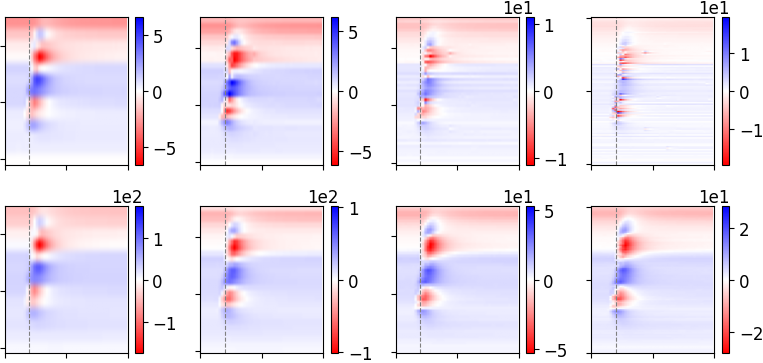

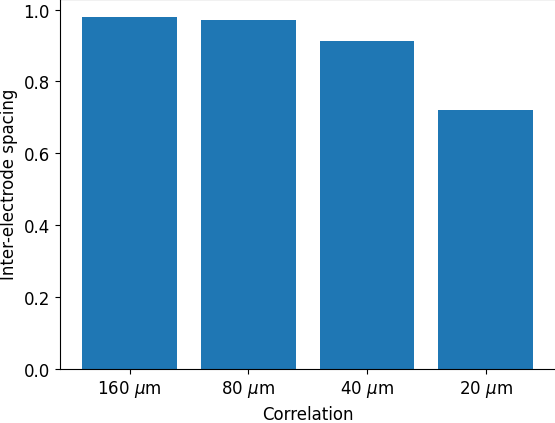

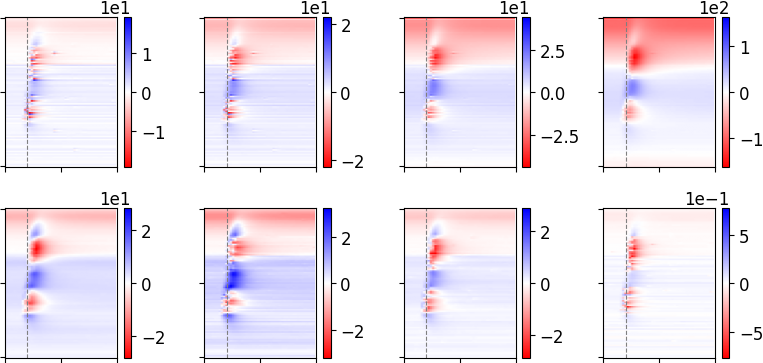

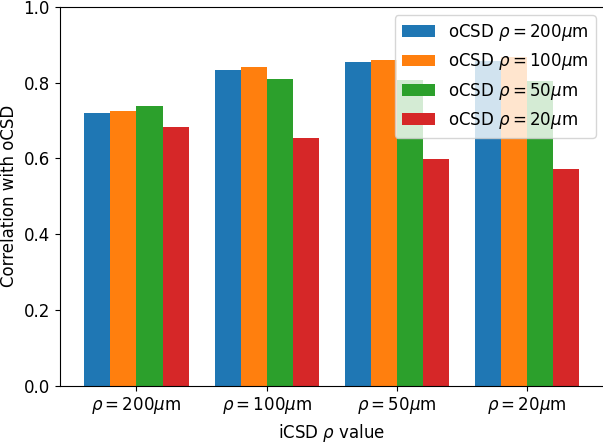

In [66]:
fig, axes = plt.subplots(2,4,figsize=(8,4))

plotFig(axes[0][0],icsd_quarter_NoNoiseNoActive_200.get_csd())
plotFig(axes[0][1],icsd_half_NoNoiseNoActive_200.get_csd())
plotFig(axes[0][2],icsd_low_NoNoiseNoActive_200.get_csd())
plotFig(axes[0][3],icsd_high_NoNoiseNoActive_200.get_csd())

plotFig(axes[1][0],ocsd_quarter_noNoiseNoActive_200.T)
plotFig(axes[1][1],ocsd_half_noNoiseNoActive_200.T)
plotFig(axes[1][2],ocsd_low_noNoiseNoActive_200.T)
plotFig(axes[1][3],ocsd_noNoiseNoActive_200.T)

for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()

corrQuarter = (twoD_correlation(icsd_quarter_NoNoiseNoActive_200.get_csd(),ocsd_quarter_noNoiseNoActive_200.T))
corrHalf = (twoD_correlation(icsd_half_NoNoiseNoActive_200.get_csd(),ocsd_half_noNoiseNoActive_200.T))
corrLow = (twoD_correlation(icsd_low_NoNoiseNoActive_200.get_csd(),ocsd_low_noNoiseNoActive_200.T))
corrHigh = (twoD_correlation(icsd_high_NoNoiseNoActive_200.get_csd(),ocsd_noNoiseNoActive_200.T))

fig, ax = plt.subplots(1)
plt.bar(np.arange(4), [corrQuarter, corrHalf, corrLow, corrHigh])
ax.set_xticks([0,1,2,3])
ax.set_xticklabels([r'160 $\mu$m',r'80 $\mu$m',r'40 $\mu$m',r'20 $\mu$m'])
plt.xlabel('Correlation')
plt.ylabel('Inter-electrode spacing')

fig, axes = plt.subplots(2,4,figsize=(8,4))
plotFig(axes[0][0],icsd_high_NoNoiseNoActive_200.get_csd())
plotFig(axes[0][1],icsd_high_NoNoiseNoActive_100.get_csd())
plotFig(axes[0][2],icsd_high_NoNoiseNoActive_50.get_csd())
plotFig(axes[0][3],icsd_high_NoNoiseNoActive_20.get_csd())
# plotFig(axes[1][0],sCsd_high_new.get_csd())
# plotFig(axes[1][1],sCsd_high_new.get_csd())
# plotFig(axes[1][2],sCsd_high_new.get_csd())
# plotFig(axes[1][3],sCsd_high_new.get_csd())
# plotFig(axes[2][0],nncsd.T)
# plotFig(axes[2][1],nncsd.T)
# plotFig(axes[2][2],nncsd.T)
# plotFig(axes[2][3],nncsd.T)
plotFig(axes[1][0],ocsd_noNoiseNoActive_200.T)
plotFig(axes[1][1],ocsd_noNoiseNoActive_100.T)
plotFig(axes[1][2],ocsd_noNoiseNoActive_50.T)
plotFig(axes[1][3],ocsd_noNoiseNoActive_20.T)

# Add vertical dashed line at t=10 to all subplots
for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
#plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/radii.png',dpi=600)

crossRhoCorrelations = np.zeros((4,4))
icsdList = [icsd_high_NoNoiseNoActive_200.get_csd(),icsd_high_NoNoiseNoActive_100.get_csd(),icsd_high_NoNoiseNoActive_50.get_csd(),icsd_high_NoNoiseNoActive_20.get_csd()]
ocsdList = [ocsd_noNoiseNoActive_200.T,ocsd_noNoiseNoActive_100.T,ocsd_noNoiseNoActive_50.T,ocsd_noNoiseNoActive_20.T]
for i in range(4):
    for j in range(4):
        corr = twoD_correlation(icsdList[i],ocsdList[j])
        crossRhoCorrelations[i,j] = corr

print(crossRhoCorrelations)

plt.figure()

n_groups, n_bars = crossRhoCorrelations.shape
x = np.arange(n_groups)
width = 0.8 / n_bars  # total group width = 0.8

for i in range(n_bars):
    plt.bar(x + i * width, crossRhoCorrelations[:, i], width=width, label=f'Category {i+1}')

plt.xticks(x + width * (n_bars - 1) / 2, [r'$\rho=200\mu$m',r'$\rho=100\mu$m',r'$\rho=50\mu$m',r'$\rho=20\mu$m'])
plt.xlabel(r"iCSD $\rho$ value")
plt.ylabel("Correlation with oCSD")
plt.legend([r'oCSD $\rho=200\mu$m',r'oCSD $\rho=100\mu$m',r'oCSD $\rho=50\mu$m',r'oCSD $\rho=20\mu$m'])
plt.ylim([0,1])
plt.tight_layout()


[[0.47450131 0.38774235 0.51733149 0.58062533]
 [0.6651117  0.55705452 0.65579734 0.59720501]
 [0.81104503 0.6919629  0.73781349 0.53344802]
 [0.82484309 0.70832302 0.71427692 0.43761896]]


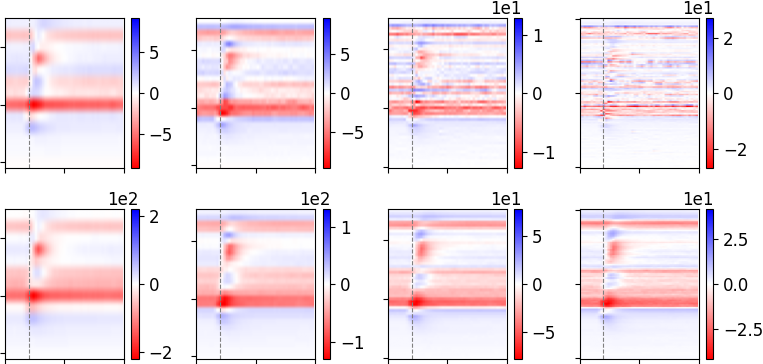

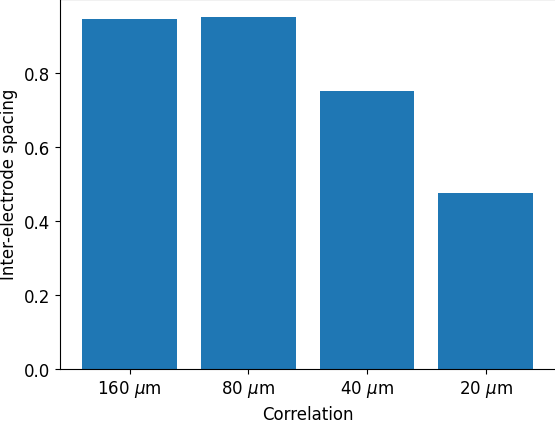

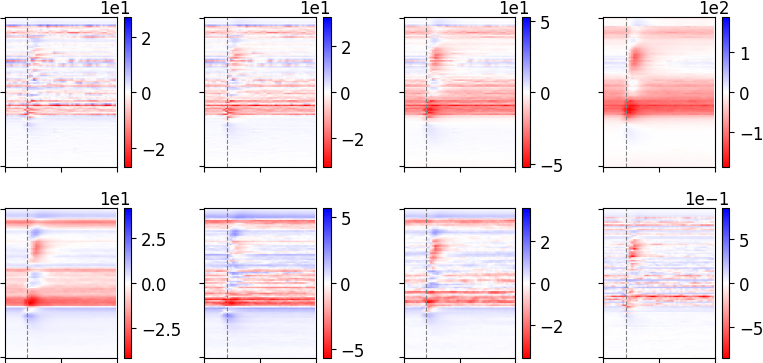

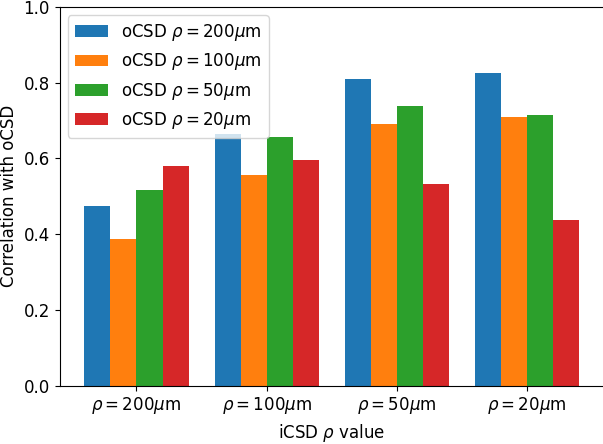

In [67]:
fig, axes = plt.subplots(2,4,figsize=(8,4))

plotFig(axes[0][0],icsd_quarter_NoActive_200.get_csd())
plotFig(axes[0][1],icsd_half_NoActive_200.get_csd())
plotFig(axes[0][2],icsd_low_NoActive_200.get_csd())
plotFig(axes[0][3],icsd_high_NoActive_200.get_csd())

plotFig(axes[1][0],ocsd_quarter_NoActive_200.T)
plotFig(axes[1][1],ocsd_half_NoActive_200.T)
plotFig(axes[1][2],ocsd_low_NoActive_200.T)
plotFig(axes[1][3],ocsd_NoActive_200.T)

for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()

corrQuarter = (twoD_correlation(icsd_quarter_NoActive_200.get_csd(),ocsd_quarter_NoActive_200.T))
corrHalf = (twoD_correlation(icsd_half_NoActive_200.get_csd(),ocsd_half_NoActive_200.T))
corrLow = (twoD_correlation(icsd_low_NoActive_200.get_csd(),ocsd_low_NoActive_200.T))
corrHigh = (twoD_correlation(icsd_high_NoActive_200.get_csd(),ocsd_NoActive_200.T))

fig, ax = plt.subplots(1)
plt.bar(np.arange(4), [corrQuarter, corrHalf, corrLow, corrHigh])
ax.set_xticks([0,1,2,3])
ax.set_xticklabels([r'160 $\mu$m',r'80 $\mu$m',r'40 $\mu$m',r'20 $\mu$m'])
plt.xlabel('Correlation')
plt.ylabel('Inter-electrode spacing')

fig, axes = plt.subplots(2,4,figsize=(8,4))
plotFig(axes[0][0],icsd_high_NoActive_200.get_csd())
plotFig(axes[0][1],icsd_high_NoActive_100.get_csd())
plotFig(axes[0][2],icsd_high_NoActive_50.get_csd())
plotFig(axes[0][3],icsd_high_NoActive_20.get_csd())
# plotFig(axes[1][0],sCsd_high_new.get_csd())
# plotFig(axes[1][1],sCsd_high_new.get_csd())
# plotFig(axes[1][2],sCsd_high_new.get_csd())
# plotFig(axes[1][3],sCsd_high_new.get_csd())
# plotFig(axes[2][0],nncsd.T)
# plotFig(axes[2][1],nncsd.T)
# plotFig(axes[2][2],nncsd.T)
# plotFig(axes[2][3],nncsd.T)
plotFig(axes[1][0],ocsd_NoActive_200.T)
plotFig(axes[1][1],ocsd_NoActive_100.T)
plotFig(axes[1][2],ocsd_NoActive_50.T)
plotFig(axes[1][3],ocsd_NoActive_20.T)

# Add vertical dashed line at t=10 to all subplots
for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
#plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/radii.png',dpi=600)

crossRhoCorrelations = np.zeros((4,4))
icsdList = [icsd_high_NoActive_200.get_csd(),icsd_high_NoActive_100.get_csd(),icsd_high_NoActive_50.get_csd(),icsd_high_NoActive_20.get_csd()]
ocsdList = [ocsd_NoActive_200.T,ocsd_NoActive_100.T,ocsd_NoActive_50.T,ocsd_NoActive_20.T]
for i in range(4):
    for j in range(4):
        corr = twoD_correlation(icsdList[i],ocsdList[j])
        crossRhoCorrelations[i,j] = corr

print(crossRhoCorrelations)

plt.figure()

n_groups, n_bars = crossRhoCorrelations.shape
x = np.arange(n_groups)
width = 0.8 / n_bars  # total group width = 0.8

for i in range(n_bars):
    plt.bar(x + i * width, crossRhoCorrelations[:, i], width=width, label=f'Category {i+1}')

plt.xticks(x + width * (n_bars - 1) / 2, [r'$\rho=200\mu$m',r'$\rho=100\mu$m',r'$\rho=50\mu$m',r'$\rho=20\mu$m'])
plt.xlabel(r"iCSD $\rho$ value")
plt.ylabel("Correlation with oCSD")
plt.legend([r'oCSD $\rho=200\mu$m',r'oCSD $\rho=100\mu$m',r'oCSD $\rho=50\mu$m',r'oCSD $\rho=20\mu$m'])
plt.ylim([0,1])
plt.tight_layout()


[[0.41508242 0.47633531 0.58520322 0.65137888]
 [0.66497926 0.6739763  0.71982998 0.61594277]
 [0.80856515 0.76579898 0.74223914 0.48428014]
 [0.83768022 0.77104945 0.70985023 0.38333622]]


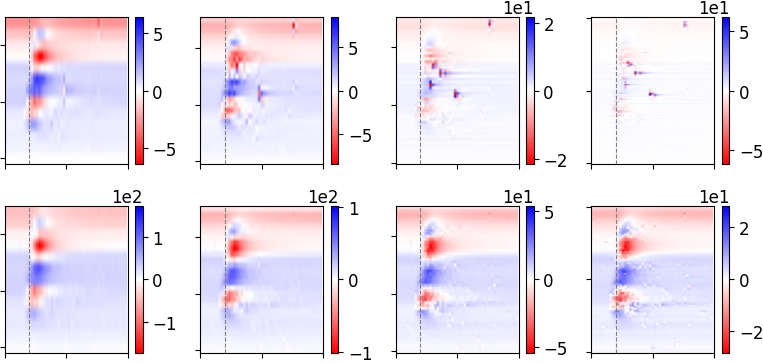

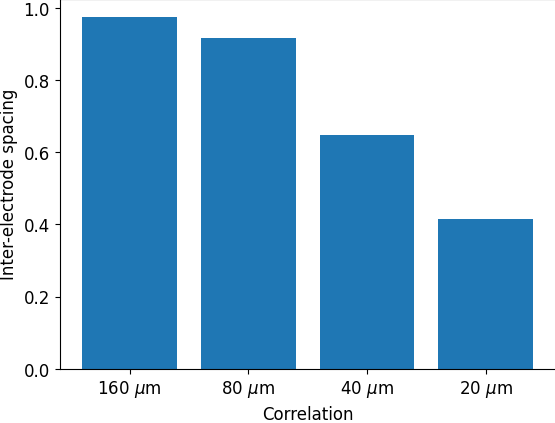

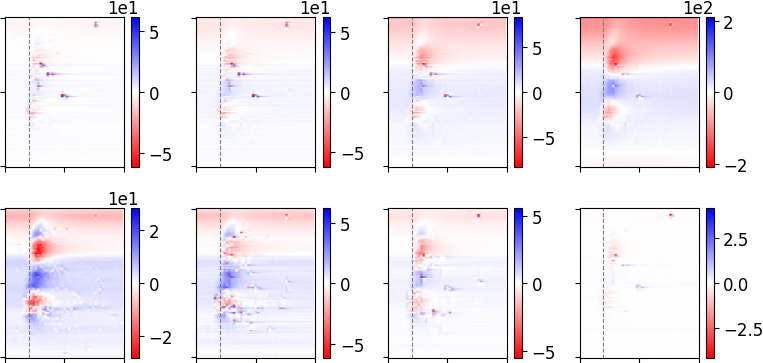

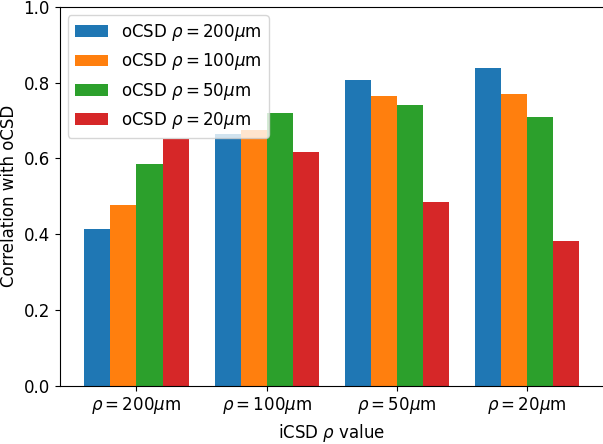

In [70]:
fig, axes = plt.subplots(2,4,figsize=(8,4))

plotFig(axes[0][0],icsd_quarter_NoNoise_200.get_csd())
plotFig(axes[0][1],icsd_half_NoNoise_200.get_csd())
plotFig(axes[0][2],icsd_low_NoNoise_200.get_csd())
plotFig(axes[0][3],icsd_high_NoNoise_200.get_csd())

plotFig(axes[1][0],ocsd_quarter_noNoise_200.T)
plotFig(axes[1][1],ocsd_half_noNoise_200.T)
plotFig(axes[1][2],ocsd_low_noNoise_200.T)
plotFig(axes[1][3],ocsd_noNoise_200.T)

for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()

corrQuarter = (twoD_correlation(icsd_quarter_NoNoise_200.get_csd(),ocsd_quarter_noNoise_200.T))
corrHalf = (twoD_correlation(icsd_half_NoNoise_200.get_csd(),ocsd_half_noNoise_200.T))
corrLow = (twoD_correlation(icsd_low_NoNoise_200.get_csd(),ocsd_low_noNoise_200.T))
corrHigh = (twoD_correlation(icsd_high_NoNoise_200.get_csd(),ocsd_noNoise_200.T))

fig, ax = plt.subplots(1)
plt.bar(np.arange(4), [corrQuarter, corrHalf, corrLow, corrHigh])
ax.set_xticks([0,1,2,3])
ax.set_xticklabels([r'160 $\mu$m',r'80 $\mu$m',r'40 $\mu$m',r'20 $\mu$m'])
plt.xlabel('Correlation')
plt.ylabel('Inter-electrode spacing')

fig, axes = plt.subplots(2,4,figsize=(8,4))
plotFig(axes[0][0],icsd_high_NoNoise_200.get_csd())
plotFig(axes[0][1],icsd_high_NoNoise_100.get_csd())
plotFig(axes[0][2],icsd_high_NoNoise_50.get_csd())
plotFig(axes[0][3],icsd_high_NoNoise_20.get_csd())
# plotFig(axes[1][0],sCsd_high_new.get_csd())
# plotFig(axes[1][1],sCsd_high_new.get_csd())
# plotFig(axes[1][2],sCsd_high_new.get_csd())
# plotFig(axes[1][3],sCsd_high_new.get_csd())
# plotFig(axes[2][0],nncsd.T)
# plotFig(axes[2][1],nncsd.T)
# plotFig(axes[2][2],nncsd.T)
# plotFig(axes[2][3],nncsd.T)
plotFig(axes[1][0],ocsd_noNoise_200.T)
plotFig(axes[1][1],ocsd_noNoise_100.T)
plotFig(axes[1][2],ocsd_noNoise_50.T)
plotFig(axes[1][3],ocsd_noNoise_20.T)

# Add vertical dashed line at t=10 to all subplots
for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
#plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/radii.png',dpi=600)

crossRhoCorrelations = np.zeros((4,4))
icsdList = [icsd_high_NoNoise_200.get_csd(),icsd_high_NoNoise_100.get_csd(),icsd_high_NoNoise_50.get_csd(),icsd_high_NoNoise_20.get_csd()]
ocsdList = [ocsd_noNoise_200.T,ocsd_noNoise_100.T,ocsd_noNoise_50.T,ocsd_noNoise_20.T]
for i in range(4):
    for j in range(4):
        corr = twoD_correlation(icsdList[i],ocsdList[j])
        crossRhoCorrelations[i,j] = corr

print(crossRhoCorrelations)

plt.figure()

n_groups, n_bars = crossRhoCorrelations.shape
x = np.arange(n_groups)
width = 0.8 / n_bars  # total group width = 0.8

for i in range(n_bars):
    plt.bar(x + i * width, crossRhoCorrelations[:, i], width=width, label=f'Category {i+1}')

plt.xticks(x + width * (n_bars - 1) / 2, [r'$\rho=200\mu$m',r'$\rho=100\mu$m',r'$\rho=50\mu$m',r'$\rho=20\mu$m'])
plt.xlabel(r"iCSD $\rho$ value")
plt.ylabel("Correlation with oCSD")
plt.legend([r'oCSD $\rho=200\mu$m',r'oCSD $\rho=100\mu$m',r'oCSD $\rho=50\mu$m',r'oCSD $\rho=20\mu$m'])
plt.ylim([0,1])
plt.tight_layout()

In [ ]:
fig, axes = plt.subplots(2,4,figsize=(8,4))

plotFig(axes[0][0],icsd_quarter_new_500.get_csd())
plotFig(axes[0][1],icsd_half_new_500.get_csd())
plotFig(axes[0][2],icsd_low_new_500.get_csd())
plotFig(axes[0][3],icsd_high_new_500.get_csd())

plotFig(axes[1][0],ocsd_quarter_500.T)
plotFig(axes[1][1],ocsd_half_500.T)
plotFig(axes[1][2],ocsd_low_500.T)
plotFig(axes[1][3],ocsd_500.T)

for ax in axes.flat:
    ax.axvline(x=10, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()

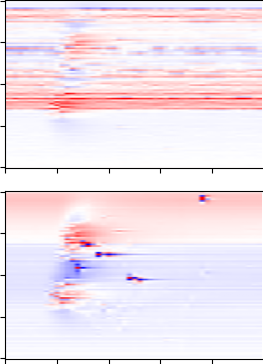

In [12]:
fig, axes = plt.subplots(2,1,figsize=(3,4))

plotFig(axes[0],icsd_high_NoActive_100.get_csd())
plotFig(axes[1],icsd_high_NoNoise_100.get_csd())

In [20]:
highResNoRecurrent

array([[-2.1840491e-05, -2.2282356e-05, -2.2566492e-05, ...,
                   nan,            nan,            nan],
       [-2.0500956e-05, -2.0668207e-05, -2.0478456e-05, ...,
                   nan,            nan,            nan],
       [-2.0211168e-05, -2.0293484e-05, -2.0027457e-05, ...,
                   nan,            nan,            nan],
       ...,
       [-4.5180032e-06, -3.2869550e-06, -2.0019561e-06, ...,
                   nan,            nan,            nan],
       [-5.7622810e-06, -4.4081817e-06, -3.1514553e-06, ...,
                   nan,            nan,            nan],
       [-5.5809869e-06, -3.6413057e-06, -2.0055722e-06, ...,
                   nan,            nan,            nan]],
      shape=(50, 607), dtype=float32)

In [15]:
original_csd = np.load('/mnt/c/Users/tharayil/Downloads/csd_paper/radii/total.npy')[50:-1]
original_csd_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Downloads/csd_paper/radii/0/pkls/eegL4_SSC.pkl').values[50:-1]
original_csd_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Downloads/csd_paper/radii/0/pkls/eegL5_TPC:A.pkl').values[50:-1]

idx_100 = np.arange(101,202) # Indices in the output file for objective disk CSD with 100 um rho
idx_50 = np.arange(202,303) # Indices in the output file for objective disk CSD with 500 um rho
idx_20 = np.arange(303,404) # Indices in the output file for objective disk CSD with 20 um rho

# ocsd_original_500 = produce_oCSD(highResOriginal,lfpIdx,np.arange(202,303))
# ocsd_original_100 = produce_oCSD(original_csd,lfpIdx,idx_100)
# ocsd_original_50 = produce_oCSD(original_csd,lfpIdx,idx_50)
# ocsd_original_20 = produce_oCSD(original_csd,lfpIdx,idx_20)

# Note that the order for these is intentionally weird since we combined a bunch of files to make the electrode weights file
ocsd_original_500 = produce_oCSD(highResOriginal,lfpIdx,np.arange(101,202))
ocsd_original_100 = produce_oCSD(highResOriginal,lfpIdx,np.arange(404,505))
ocsd_original_50 = produce_oCSD(highResOriginal,lfpIdx,np.arange(303,404))
ocsd_original_20 = produce_oCSD(highResOriginal,lfpIdx,np.arange(505,606))

ocsd_l4_500 = produce_oCSD(L4original,lfpIdx,np.arange(202,303))
ocsd_l4_100 = produce_oCSD(original_csd_l4,lfpIdx,idx_100)
ocsd_l4_50 = produce_oCSD(original_csd_l4,lfpIdx,idx_50)
ocsd_l4_20 = produce_oCSD(original_csd_l4,lfpIdx,idx_20)

ocsd_l5_500 = produce_oCSD(L5original,lfpIdx,np.arange(202,303))
ocsd_l5_100 = produce_oCSD(original_csd_l5,lfpIdx,idx_100)
ocsd_l5_50 = produce_oCSD(original_csd_l5,lfpIdx,idx_50)
ocsd_l5_20 = produce_oCSD(original_csd_l5,lfpIdx,idx_20)

idx_100 = np.arange(101) # Indices in the output file for objective disk CSD with 100 um rho
idx_50 = np.arange(101,202) # Indices in the output file for objective disk CSD with 500 um rho
idx_20 = np.arange(101) # Indices in the output file for objective disk CSD with 20 um rho

noRecurrent_largeradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_midRho/total.npy')
noRecurrent_largeradius_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_midRho/0/pkls/eegL4_SSC.pkl').values
noRecurrent_largeradius_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_midRho/0/pkls/eegL5_TPC:A.pkl').values
noRecurrent_50 = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_50um/total.npy')


noRecurrent_smallradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_smallRho/total.npy')
noRecurrent_smallradius_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_smallRho/0/pkls/eegL4_SSC.pkl').values
noRecurrent_smallradius_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noRecurrentConnecvitity_smallRho/0/pkls/eegL5_TPC:A.pkl').values

#ocsd_noRecurrent_500, ocsd_low_noRecurrent_500, ocsd_half_noRecurrent_500, ocsd_quarter_noRecurrent_500 = produce_oCSD_all(highResNoRecurrent,lfpIdx,idx_50)    
#ocsd_noRecurrent_100, ocsd_low_noRecurrent_100, ocsd_half_noRecurrent_100, ocsd_quarter_noRecurrent_100 = produce_oCSD_all(noRecurrent_largeradius,lfpIdx,idx_100)
#ocsd_noRecurrent_50 = produce_oCSD(noRecurrent_50,lfpIdx,np.arange(303,404))
#ocsd_noRecurrent_20, ocsd_low_noRecurrent_20, ocsd_half_noRecurrent_20, ocsd_quarter_noRecurrent_20 = produce_oCSD_all(noRecurrent_smallradius,lfpIdx,idx_20)

# Here we recalculate oCSD for noRecurrent using the averaged data from noRecurrent_50um
ocsd_noRecurrent_500, ocsd_low_noRecurrent_500, ocsd_half_noRecurrent_500, ocsd_quarter_noRecurrent_500 = produce_oCSD_all(highResNoRecurrent,lfpIdx,np.arange(101,202))    
ocsd_noRecurrent_100, ocsd_low_noRecurrent_100, ocsd_half_noRecurrent_100, ocsd_quarter_noRecurrent_100 = produce_oCSD_all(highResNoRecurrent,lfpIdx,np.arange(404,505))
ocsd_noRecurrent_50 = produce_oCSD(highResNoRecurrent,lfpIdx,np.arange(303,404))
ocsd_noRecurrent_20, ocsd_low_noRecurrent_20, ocsd_half_noRecurrent_20, ocsd_quarter_noRecurrent_20 = produce_oCSD_all(highResNoRecurrent,lfpIdx,np.arange(505,606))


ocsd_noRecurrent_l4_500 = produce_oCSD(L4NoRecurrent,lfpIdx,idx_50)    
ocsd_noRecurrent_l4_100 = produce_oCSD(noRecurrent_largeradius_l4,lfpIdx,idx_100)
# ocsd_noRecurrent_l4_50 = produce_oCSD(noRecurrent_largeradius_l4,lfpIdx,idx_50)
ocsd_noRecurrent_l4_20 = produce_oCSD(noRecurrent_smallradius_l4,lfpIdx,idx_20)

ocsd_noRecurrent_l5_500 = produce_oCSD(L5NoRecurrent,lfpIdx,idx_50)    
ocsd_noRecurrent_l5_100 = produce_oCSD(noRecurrent_largeradius_l5,lfpIdx,idx_100)
# ocsd_noRecurrent_l5_50 = produce_oCSD(noRecurrent_largeradius_l5,lfpIdx,idx_50)
ocsd_noRecurrent_l5_20 = produce_oCSD(noRecurrent_smallradius_l5,lfpIdx,idx_20)

noActive_largeradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_midRho//total.npy')
noActive_largeradius_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_midRho/0/pkls/eegL4_SSC.pkl').values
noActive_largeradius_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_midRho/0/pkls/eegL5_TPC:A.pkl').values

noActive_smallradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_smallRho//total.npy')
noActive_smallradius_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_smallRho/0/pkls/eegL4_SSC.pkl').values
noActive_smallradius_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_withNoise_smallRho/0/pkls/eegL5_TPC:A.pkl').values

ocsd_noActive_500, ocsd_low_noActive_500, ocsd_half_noActive_500, ocsd_quarter_noActive_500 = produce_oCSD_all(highResNoActive,lfpIdx,idx_50) # Note that idx_50 is correct here
ocsd_noActive_100, ocsd_low_noActive_100, ocsd_half_noActive_100, ocsd_quarter_noActive_100 = produce_oCSD_all(noActive_largeradius,lfpIdx,idx_100)
#ocsd_noActive_50 = produce_oCSD(noActive_largeradius,lfpIdx,idx_50)
ocsd_noActive_20, ocsd_low_noActive_20, ocsd_half_noActive_20, ocsd_quarter_noActive_20 = produce_oCSD_all(noActive_smallradius,lfpIdx,idx_20)

ocsd_noActive_l4_500 = produce_oCSD(L4NoActive,lfpIdx,idx_50) 
ocsd_noActive_l4_100 = produce_oCSD(noActive_largeradius_l4,lfpIdx,idx_100)
# ocsd_noActive_l4_50 = produce_oCSD(noActive_largeradius_l4,lfpIdx,idx_50)
ocsd_noActive_l4_20 = produce_oCSD(noActive_smallradius_l4,lfpIdx,idx_20)

ocsd_noActive_l5_500 = produce_oCSD(L5NoActive,lfpIdx,idx_50) 
ocsd_noActive_l5_100 = produce_oCSD(noActive_largeradius_l5,lfpIdx,idx_100)
# ocsd_noActive_l5_50 = produce_oCSD(noActive_largeradius_l5,lfpIdx,idx_50)
ocsd_noActive_l5_20 = produce_oCSD(noActive_smallradius_l5,lfpIdx,idx_20)

noNoise_largeradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_midRho/total.npy')
noNoise_largeradius_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_midRho/0/pkls/eegL4_SSC.pkl').values
noNoise_largeradius_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_midRho/0/pkls/eegL5_TPC:A.pkl').values
noNoise_50 = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_50um/total.npy')

noNoise_smallradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_smallRho/total.npy')
noNoise_smallradius_l4 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_smallRho/0/pkls/eegL4_SSC.pkl').values
noNoise_smallradius_l5 = pd.read_pickle('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noNoise_smallRho/0/pkls/eegL5_TPC:A.pkl').values

ocsd_noNoise_500, ocsd_low_noNoise_500, ocsd_half_noNoise_500, ocsd_quarter_noNoise_500 = produce_oCSD_all(highResNoNoise,lfpIdx,idx_50)
ocsd_noNoise_100, ocsd_low_noNoise_100, ocsd_half_noNoise_100, ocsd_quarter_noNoise_100 = produce_oCSD_all(noNoise_largeradius,lfpIdx,idx_100)
ocsd_noNoise_50 = produce_oCSD(noNoise_50,lfpIdx,np.arange(303,404))
ocsd_noNoise_20, ocsd_low_noNoise_20, ocsd_half_noNoise_20, ocsd_quarter_noNoise_20 = produce_oCSD_all(noNoise_smallradius,lfpIdx,idx_20)

ocsd_noNoise_l4_500 = produce_oCSD(L4NoNoise,lfpIdx,idx_50) 
ocsd_noNoise_l4_100 = produce_oCSD(noNoise_largeradius_l4,lfpIdx,idx_100)
# ocsd_noNoise_l4_50 = produce_oCSD(noNoise_largeradius_l4,lfpIdx,idx_50)
ocsd_noNoise_l4_20 = produce_oCSD(noNoise_smallradius_l4,lfpIdx,idx_20)

ocsd_noNoise_l5_500 = produce_oCSD(L5NoNoise,lfpIdx,idx_50) 
ocsd_noNoise_l5_100 = produce_oCSD(noNoise_largeradius_l5.copy(),lfpIdx,idx_100)
# ocsd_noNoise_l5_50 = produce_oCSD(noNoise_largeradius_l5.copy(),lfpIdx,idx_50)
ocsd_noNoise_l5_20 = produce_oCSD(noNoise_smallradius_l5,lfpIdx,idx_20)


NoActive_largeradius = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_midRho/total.npy')

ocsd_noNoiseNoActive_100, ocsd_low_noNoiseNoActive_100, ocsd_half_noNoiseNoActive_100, ocsd_quarter_noNoiseNoActive_100 = produce_oCSD_all(noNoiseNoActive_largeradius,lfpIdx,idx_100)

noNoiseNoActive_50 = np.load('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/noActive_50um/total.npy')

ocsd_noNoiseNoActive_50, ocsd_low_noNoiseNoActive_50, ocsd_half_noNoiseNoActive_50, ocsd_quarter_noNoiseNoActive_50 = produce_oCSD_all(noNoiseNoActive_50,lfpIdx,np.arange(303,404))
                                

In [13]:
def getMeanCorrelation(icsd,ocsd):

    from scipy.stats import wasserstein_distance

    correlations = []
    distances = []
    icsdVal = icsd.get_csd()

    rms = np.mean(np.sqrt(icsdVal**2))

    icsdVal /=  rms

    rms = np.mean(np.sqrt(ocsd**2))

    ocsd /= rms

    for i in range(icsdVal.shape[1]):
        distances.append(wasserstein_distance(icsdVal[:,i],ocsd.T[:,i]))
        correlations.append(np.corrcoef(icsdVal[:,i],ocsd.T[:,i])[0,1])

    return np.mean(correlations), np.mean(distances)

In [20]:
def getMeanCorrelation(a, b):
    """
    Compute the normalized 2D cross-correlation between two arrays.
    Result values range from -1 (anticorrelated) to 1 (perfectly correlated).
    """
    a = a.get_csd().astype(float)
    b = b.T
    b = b.astype(float)
    a_mean = a.mean()
    b_mean = b.mean()
    num = np.sum((a - a_mean) * (b - b_mean))
    den = np.sqrt(np.sum((a - a_mean)**2) * np.sum((b - b_mean)**2))

    return num/den, None

In [26]:
np.sum(np.sqrt(np.random.rand(100)**2))

np.float64(48.243402005564214)

In [14]:
def producePlotAndCorrelation(icsd,ocsd,icsdL4,ocsdL4,icsdL5,ocsdL5):

    fig, axes = plt.subplots(2,3,figsize=(6,4))

    plotFig(axes[0][0],icsd.get_csd())
    plotFig(axes[1][0],ocsd.T)
    
    plotFig(axes[0][1],icsdL4.get_csd())
    plotFig(axes[1][1],ocsdL4.T)
    
    plotFig(axes[0][2],icsdL5.get_csd())
    plotFig(axes[1][2],ocsdL5.T)

    correlations = [getMeanCorrelation(icsd,ocsd)[0],getMeanCorrelation(icsdL4,ocsdL4)[0],getMeanCorrelation(icsdL5,ocsdL5)[0]]
    distances = [getMeanCorrelation(icsd,ocsd)[1],getMeanCorrelation(icsdL4,ocsdL4)[1],getMeanCorrelation(icsdL5,ocsdL5)[1]]

    return correlations, distances

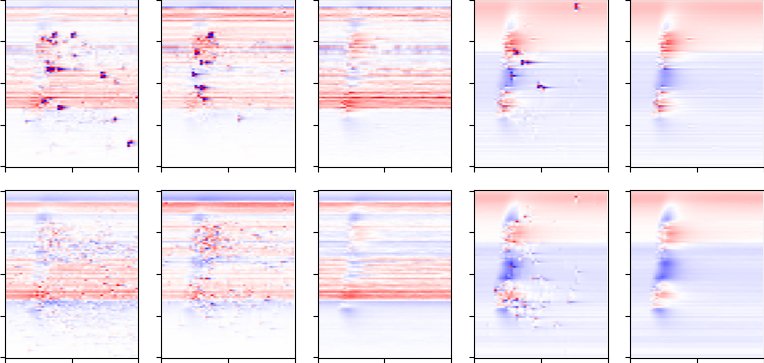

In [36]:
fig, axes = plt.subplots(2,5,figsize=(8,4))

plotFig(axes[0][0],icsd_high_original_100.get_csd())
plotFig(axes[1][0],ocsd_original_100.T)

plotFig(axes[0][1],icsd_high_noRecurrent_100.get_csd())
plotFig(axes[1][1],ocsd_noRecurrent_100.T)

plotFig(axes[0][2],icsd_high_NoActive_100.get_csd())
plotFig(axes[1][2],ocsd_noActive_100.T)

plotFig(axes[0][3],icsd_high_NoNoise_100.get_csd())
plotFig(axes[1][3],ocsd_noNoise_100.T)

plotFig(axes[0][4],icsd_high_NoNoiseNoActive_100.get_csd())
plotFig(axes[1][4],ocsd_noNoiseNoActive_100.T)

plt.tight_layout()

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/explainPriorWork_expanded_fixIntegration_100.png',dpi=600)


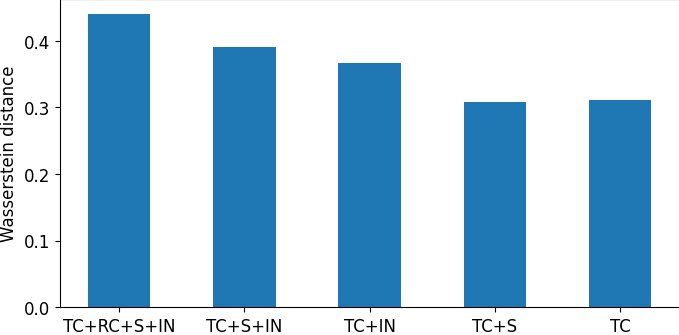

In [35]:
correlationOriginal, distanceOriginal = getMeanCorrelation(icsd_high_original_100,ocsd_original_100)
correlationNoRecurrent, distanceNoRecurrent = getMeanCorrelation(icsd_high_noRecurrent_100,ocsd_noRecurrent_100)
correlationNoActive, distanceNoActive = getMeanCorrelation(icsd_high_NoActive_100,ocsd_noActive_100)
correlationNoNoise, distanceNoNoise = getMeanCorrelation(icsd_high_NoNoise_100,ocsd_noNoise_100)
correlationNoActiveNoNoise, distanceNoActiveNoNoise = getMeanCorrelation(icsd_high_NoNoiseNoActive_100,ocsd_noNoiseNoActive_100)

fig,ax = plt.subplots(figsize=(8,4))
ax.bar(np.arange(5), [distanceOriginal, distanceNoRecurrent, distanceNoActive, distanceNoNoise, distanceNoActiveNoNoise],width=0.5)
ax.set_xticks(np.arange(5))
ax.set_xticklabels(['TC+RC+S+IN','TC+S+IN','TC+IN','TC+S','TC'])
ax.set_ylabel('Wasserstein distance')
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/explainPriorWork_barGraph.png',dpi=600)


Text(0, 0.5, 'Mean Correlation')

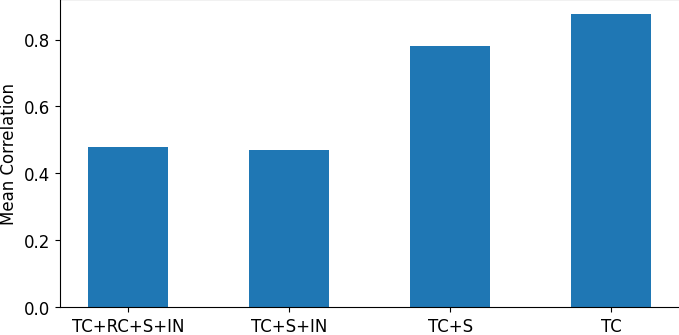

In [37]:
fig,ax = plt.subplots(figsize=(8,4))
ax.bar(np.arange(4), [correlationOriginal, correlationNoRecurrent, correlationNoNoise, correlationNoActiveNoNoise],width=0.5)
ax.set_xticks(np.arange(4))
ax.set_xticklabels(['TC+RC+S+IN','TC+S+IN','TC+S','TC'])
ax.set_ylabel('Mean Correlation')

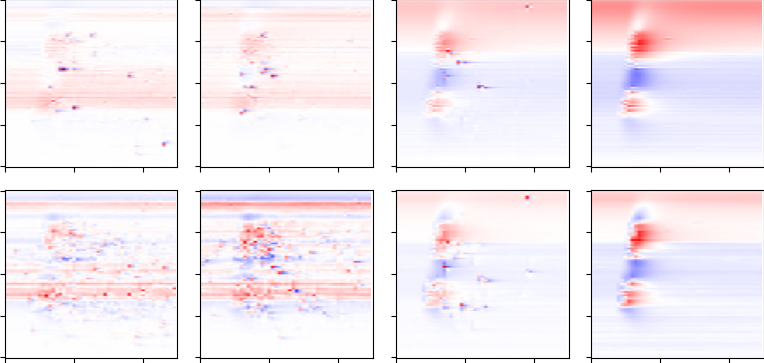

In [54]:
fig, axes = plt.subplots(2,4,figsize=(8,4))

plotFig(axes[0][0],icsd_high_original_50.get_csd())
plotFig(axes[1][0],ocsd_original_50.T)

plotFig(axes[0][1],icsd_high_noRecurrent_50.get_csd())
plotFig(axes[1][1],ocsd_noRecurrent_50.T)

plotFig(axes[0][2],icsd_high_NoNoise_50.get_csd())
plotFig(axes[1][2],ocsd_noNoise_50.T)

plotFig(axes[0][3],icsd_high_NoNoiseNoActive_50.get_csd())
plotFig(axes[1][3],ocsd_noNoiseNoActive_50.T)

plt.tight_layout()

#plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/explainPriorWork_expanded_fixIntegration_50.png',dpi=600)


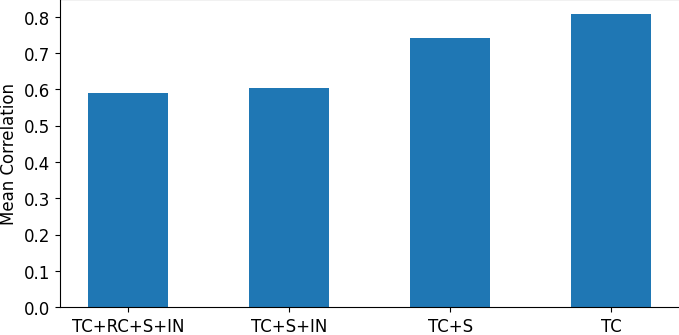

In [21]:
correlationOriginal, distanceOriginal = getMeanCorrelation(icsd_high_original_50,ocsd_original_50)
correlationNoRecurrent, distanceNoRecurrent = getMeanCorrelation(icsd_high_noRecurrent_50,ocsd_noRecurrent_50)
# _, distanceNoActive = getMeanCorrelation(icsd_high_NoActive_100,ocsd_noActive_100)
correlationNoNoise, distanceNoNoise = getMeanCorrelation(icsd_high_NoNoise_50,ocsd_noNoise_50)
correlationNoActiveNoNoise, distanceNoActiveNoNoise = getMeanCorrelation(icsd_high_NoNoiseNoActive_50,ocsd_noNoiseNoActive_50)

fig,ax = plt.subplots(figsize=(8,4))
ax.bar(np.arange(4), [correlationOriginal, correlationNoRecurrent, correlationNoNoise, correlationNoActiveNoNoise],width=0.5)
ax.set_xticks(np.arange(4))
ax.set_xticklabels(['TC+RC+S+IN','TC+S+IN','TC+S','TC'])
ax.set_ylabel('Mean Correlation')
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/explainPriorWork_barGraph_50_2d.png',dpi=600)


In [34]:
correlationNoRecurrent

np.float64(0.6188061486009674)

Text(0, 0.5, 'Wassterstein Distance')

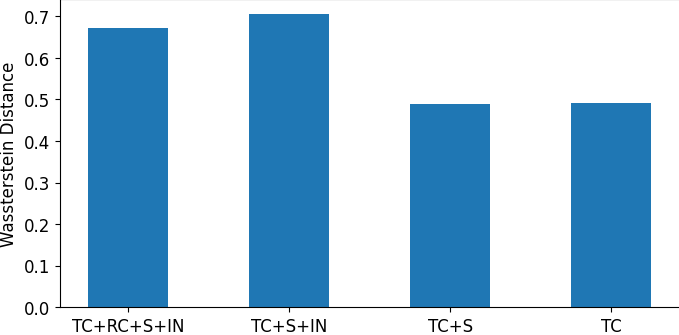

In [30]:
fig,ax = plt.subplots(figsize=(8,4))
ax.bar(np.arange(4), [distanceOriginal, distanceNoRecurrent, distanceNoNoise, distanceNoActiveNoNoise],width=0.5)
ax.set_xticks(np.arange(4))
ax.set_xticklabels(['TC+RC+S+IN','TC+S+IN','TC+S','TC'])
ax.set_ylabel('Wassterstein Distance')

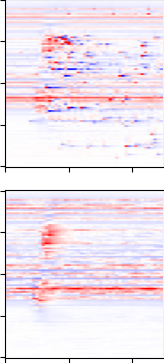

In [52]:
fig, axes = plt.subplots(2,1,figsize=(2,4))

plotFig(axes[0],ocsd_original_20.T)

plotFig(axes[1],ocsd_noActive_20.T)

plt.tight_layout()

plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/rho20Explain.png',dpi=600)

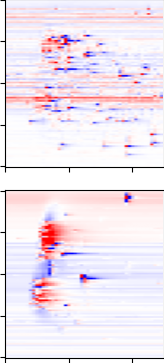

In [49]:
fig, axes = plt.subplots(2,1,figsize=(2,4))

plotFig(axes[0],ocsd_original_20.T)

plotFig(axes[1],ocsd_noNoise_20.T)

plt.tight_layout()

In [22]:
### Calculates correlations between iCSD and oCSD for all electrode spacings

correlations_high_noActive_500 = []
correlations_low_noActive_500 = []
correlations_low_half_noActive_500 = []
correlations_low_quarter_noActive_500 = []

for i in np.arange(50):
    correlations_high_noActive_500.append(np.corrcoef(icsd_high_NoActive_500.get_csd()[:,i],ocsd_noActive_500.T[:,i])[0,1])
    correlations_low_noActive_500.append(np.corrcoef(icsd_low_NoActive_500.get_csd()[:,i],ocsd_low_noActive_500.T[:,i])[0,1])
    correlations_low_half_noActive_500.append(np.corrcoef(icsd_half_NoActive_500.get_csd()[:,i],ocsd_half_noActive_500.T[:,i])[0,1])
    correlations_low_quarter_noActive_500.append(np.corrcoef(icsd_quarter_NoActive_500.get_csd()[:,i],ocsd_quarter_noActive_500.T[:,i])[0,1])

In [35]:
correlations2d_high_noActive_500,_ = getMeanCorrelation(icsd_high_NoActive_500,ocsd_noActive_500)
correlations2d_low_noActive_500,_ = getMeanCorrelation(icsd_low_NoActive_500,ocsd_low_noActive_500)
correlations2d_low_half_noActive_500,_ = getMeanCorrelation(icsd_half_NoActive_500,ocsd_half_noActive_500)
correlations2d_low_quarter_noActive_500,_ = getMeanCorrelation(icsd_quarter_NoActive_500,ocsd_quarter_noActive_500)

In [18]:
### Calculates correlations between iCSD and oCSD for all electrode spacings

correlations_high_noActive_100 = []
correlations_low_noActive_100 = []
correlations_low_half_noActive_100 = []
correlations_low_quarter_noActive_100 = []

for i in np.arange(50):
    correlations_high_noActive_100.append(np.corrcoef(icsd_high_NoActive_100.get_csd()[:,i],ocsd_noActive_100.T[:,i])[0,1])
    correlations_low_noActive_100.append(np.corrcoef(icsd_low_NoActive_100.get_csd()[:,i],ocsd_low_noActive_100.T[:,i])[0,1])
    correlations_low_half_noActive_100.append(np.corrcoef(icsd_half_NoActive_100.get_csd()[:,i],ocsd_half_noActive_100.T[:,i])[0,1])
    correlations_low_quarter_noActive_100.append(np.corrcoef(icsd_quarter_NoActive_100.get_csd()[:,i],ocsd_quarter_noActive_100.T[:,i])[0,1])

In [36]:
correlations2d_high_noActive_100,_ = getMeanCorrelation(icsd_high_NoActive_100,ocsd_noActive_100)
correlations2d_low_noActive_100,_ = getMeanCorrelation(icsd_low_NoActive_100,ocsd_low_noActive_100)
correlations2d_low_half_noActive_100,_ = getMeanCorrelation(icsd_half_NoActive_100,ocsd_half_noActive_100)
correlations2d_low_quarter_noActive_100,_ = getMeanCorrelation(icsd_quarter_NoActive_100,ocsd_quarter_noActive_100)

In [19]:
### Calculates correlations between iCSD and oCSD for all electrode spacings

correlations_high_noActive_20 = []
correlations_low_noActive_20 = []
correlations_low_half_noActive_20 = []
correlations_low_quarter_noActive_20 = []

for i in np.arange(50):
    correlations_high_noActive_20.append(np.corrcoef(icsd_high_NoActive_20.get_csd()[:,i],ocsd_noActive_20.T[:,i])[0,1])
    correlations_low_noActive_20.append(np.corrcoef(icsd_low_NoActive_20.get_csd()[:,i],ocsd_low_noActive_20.T[:,i])[0,1])
    correlations_low_half_noActive_20.append(np.corrcoef(icsd_half_NoActive_20.get_csd()[:,i],ocsd_half_noActive_20.T[:,i])[0,1])
    correlations_low_quarter_noActive_20.append(np.corrcoef(icsd_quarter_NoActive_20.get_csd()[:,i],ocsd_quarter_noActive_20.T[:,i])[0,1])

In [37]:
correlations2d_high_noActive_20,_ = getMeanCorrelation(icsd_high_NoActive_20,ocsd_noActive_20)
correlations2d_low_noActive_20,_ = getMeanCorrelation(icsd_low_NoActive_20,ocsd_low_noActive_20)
correlations2d_low_half_noActive_20,_ = getMeanCorrelation(icsd_half_NoActive_20,ocsd_half_noActive_20)
correlations2d_low_quarter_noActive_20,_ = getMeanCorrelation(icsd_quarter_NoActive_20,ocsd_quarter_noActive_20)

In [20]:
### Calculates correlations between iCSD and oCSD for all electrode spacings

noRecurrent = []
correlations_low_noRecurrent_20 = []
correlations_low_half_noRecurrent_20 = []
correlations_low_quarter_noRecurrent_20 = []

for i in np.arange(50):
    noRecurrent.append(np.corrcoef(icsd_high_noRecurrent_20.get_csd()[:,i],ocsd_noRecurrent_20.T[:,i])[0,1])
    correlations_low_noRecurrent_20.append(np.corrcoef(icsd_low_noRecurrent_20.get_csd()[:,i],ocsd_low_noRecurrent_20.T[:,i])[0,1])
    correlations_low_half_noRecurrent_20.append(np.corrcoef(icsd_half_noRecurrent_20.get_csd()[:,i],ocsd_half_noRecurrent_20.T[:,i])[0,1])
    correlations_low_quarter_noRecurrent_20.append(np.corrcoef(icsd_quarter_noRecurrent_20.get_csd()[:,i],ocsd_quarter_noRecurrent_20.T[:,i])[0,1])

In [38]:
noRecurrent2d,_ =  getMeanCorrelation(icsd_high_noRecurrent_20,ocsd_noRecurrent_20)
correlations2d_low_noRecurrent_20,_ = getMeanCorrelation(icsd_low_noRecurrent_20,ocsd_low_noRecurrent_20)
correlations2d_low_half_noRecurrent_20,_ = getMeanCorrelation(icsd_half_noRecurrent_20,ocsd_half_noRecurrent_20)
correlations2d_low_quarter_noRecurrent_20,_ = getMeanCorrelation(icsd_quarter_noRecurrent_20,ocsd_quarter_noRecurrent_20)

In [45]:
### Calculates correlations between iCSD and oCSD for all electrode spacings

noNoise = []
correlations_low_noNoise_20 = []
correlations_low_half_noNoise_20 = []
correlations_low_quarter_noNoise_20 = []

for i in np.arange(50):
    noNoise.append(np.corrcoef(icsd_high_NoNoise_20.get_csd()[:,i],ocsd_noNoise_20.T[:,i])[0,1])
    correlations_low_noNoise_20.append(np.corrcoef(icsd_low_NoNoise_20.get_csd()[:,i],ocsd_low_noNoise_20.T[:,i])[0,1])
    correlations_low_half_noNoise_20.append(np.corrcoef(icsd_half_NoNoise_20.get_csd()[:,i],ocsd_half_noNoise_20.T[:,i])[0,1])
    correlations_low_quarter_noNoise_20.append(np.corrcoef(icsd_quarter_NoNoise_20.get_csd()[:,i],ocsd_quarter_noNoise_20.T[:,i])[0,1])

In [39]:
noNoise2d,_ =  getMeanCorrelation(icsd_high_NoNoise_20,ocsd_noNoise_20)
correlations2d_low_noNoise_20,_ = getMeanCorrelation(icsd_low_NoNoise_20,ocsd_low_noNoise_20)
correlations2d_low_noNoise_20,_ = getMeanCorrelation(icsd_half_NoNoise_20,ocsd_half_noNoise_20)
correlations2d_low_noNoise_20,_ = getMeanCorrelation(icsd_quarter_NoNoise_20,ocsd_quarter_noNoise_20)

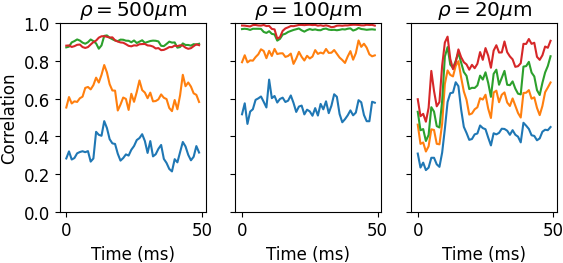

In [47]:
fig, ax = plt.subplots(1,3,figsize=(6,3))

ax[0].plot(correlations_high_noActive_500)
ax[0].plot(correlations_low_noActive_500)
ax[0].plot(correlations_low_half_noActive_500)
ax[0].plot(correlations_low_quarter_noActive_500)
ax[0].set_ylim([0,1])
ax[0].set_title(r'$\rho=500\mu$m')
ax[0].set_ylabel('Correlation')
ax[0].set_xlabel('Time (ms)')

ax[1].plot(correlations_high_noActive_100)
ax[1].plot(correlations_low_noActive_100)
ax[1].plot(correlations_low_half_noActive_100)
ax[1].plot(correlations_low_quarter_noActive_100)
ax[1].set_ylim([0,1])
ax[1].set_yticklabels([])
ax[1].set_title(r'$\rho=100\mu$m')
ax[1].set_xlabel('Time (ms)')


ax[2].plot(correlations_high_noActive_20)
ax[2].plot(correlations_low_noActive_20)
ax[2].plot(correlations_low_half_noActive_20)
ax[2].plot(correlations_low_quarter_noActive_20)
ax[2].set_ylim([0,1])
ax[2].set_yticklabels([])
ax[2].set_title(r'$\rho=20\mu$m')
ax[2].set_xlabel('Time (ms)')


plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/nonactiveAcrossRho.png',dpi=600)

In [42]:
correlations2d_test_20,_ = getMeanCorrelation(icsd_high_original_20,ocsd_original_20)


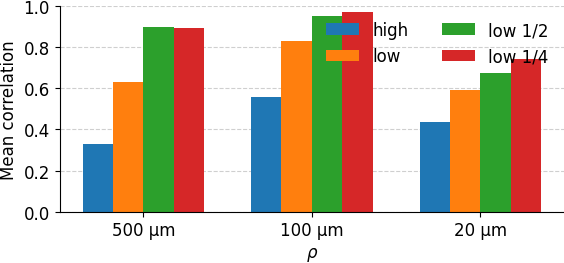

In [40]:
import numpy as np
import matplotlib.pyplot as plt  # :contentReference[oaicite:0]{index=0}

labels = ['500 μm', '100 μm', '20 μm']

# rows = conditions, columns = radii
data = np.array([
    [correlations2d_high_noActive_500,
     correlations2d_high_noActive_100,
     correlations2d_high_noActive_20],

    [correlations2d_low_noActive_500,
     correlations2d_low_noActive_100,
     correlations2d_low_noActive_20],

    [correlations2d_low_half_noActive_500,
     correlations2d_low_half_noActive_100,
     correlations2d_low_half_noActive_20],

    [correlations2d_low_quarter_noActive_500,
     correlations2d_low_quarter_noActive_100,
     correlations2d_low_quarter_noActive_20],
])

cond_labels = ['high', 'low', 'low 1/2', 'low 1/4']

x = np.arange(len(labels))
width = 0.18

fig, ax = plt.subplots(figsize=(6, 3))

for i in range(data.shape[0]):
    offsets = x + (i - (data.shape[0]-1)/2) * width
    ax.bar(offsets, data[i], width=width, label=cond_labels[i])

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Mean correlation')
ax.set_xlabel(r'$\rho$')

ax.set_ylim(0, 1)

# cleaner formatting
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_axisbelow(True)

ax.legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

In [22]:
np.mean(correlations_high_noActive_20)

np.float64(0.4124201745195084)

In [24]:
np.mean(noRecurrent)

np.float64(0.3946539857151565)

In [32]:
np.mean(correlations_test_20)

np.float64(0.3823609374995086)

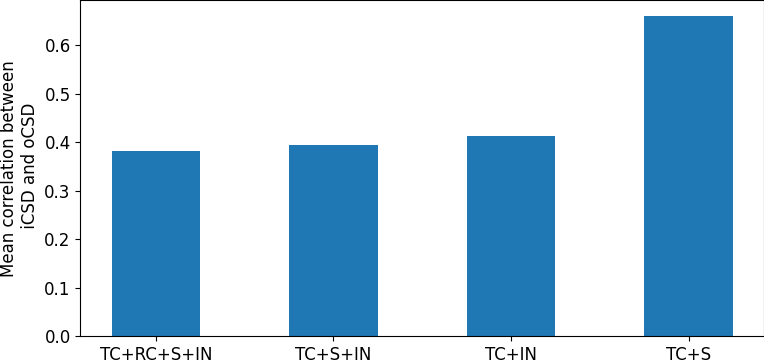

In [38]:
fig,ax = plt.subplots(figsize=(8,4))
ax.bar(np.arange(4), [np.mean(correlations_test_20), np.mean(noRecurrent), np.mean(correlations_high_noActive_20), np.mean(noNoise)],width=0.5)
ax.set_xticks(np.arange(4))
ax.set_xticklabels(['TC+RC+S+IN','TC+S+IN','TC+IN','TC+S'])
ax.set_ylabel('Mean correlation between\n iCSD and oCSD')
plt.tight_layout()
plt.savefig('/mnt/c/Users/tharayil/Documents/csdRevisions/csd_paper/hypothesisTesting/nonshiftedPositions_rerun/homogeneityAt20.png',dpi=600)


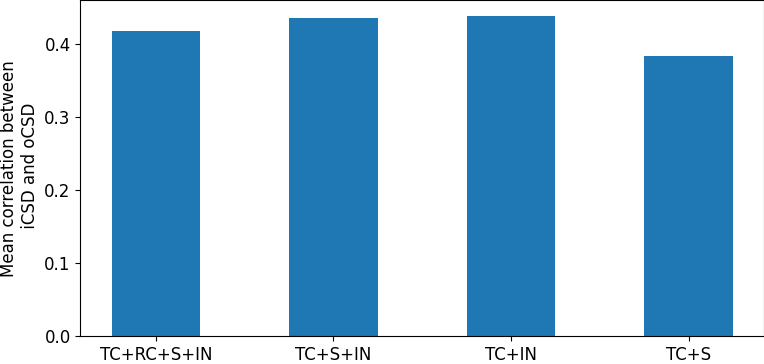

In [43]:
fig,ax = plt.subplots(figsize=(8,4))
ax.bar(np.arange(4), [correlations2d_test_20, noRecurrent2d, correlations2d_high_noActive_20, noNoise2d],width=0.5)
ax.set_xticks(np.arange(4))
ax.set_xticklabels(['TC+RC+S+IN','TC+S+IN','TC+IN','TC+S'])
ax.set_ylabel('Mean correlation between\n iCSD and oCSD')
plt.tight_layout()